Loading data from NEW-DATA-1.T15.txt...
Extracting lag features (Count: 5)...

Verifying performance with standard sklearn LinearRegression...
📊 Estimated MAE:  0.1204


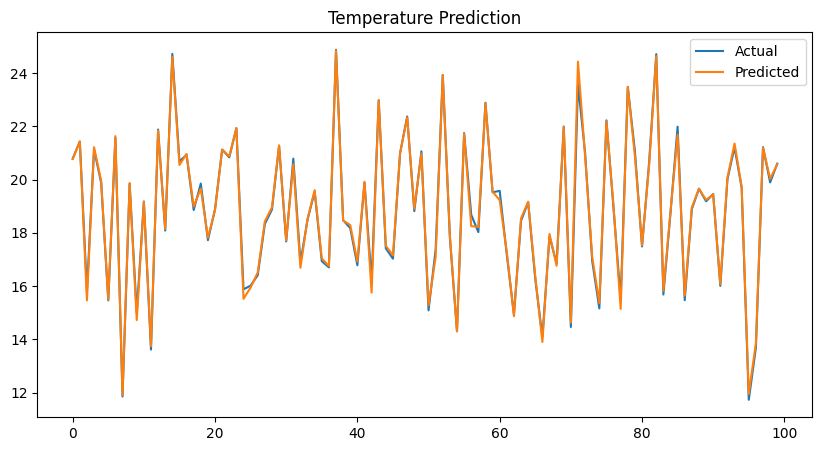


Training exportable model...
Exporting Config to exported_models\temperature_app\linear_reg_config...
✅ Done. Files generated.


In [4]:
import os
import os.path as osp
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression # Standard for checking
from sklearn.metrics import mean_absolute_error
from matplotlib import pyplot as plt
from sklearn2c import LinearRegressor # For export

# --- Configuration ---
DATA_PATH = "NEW-DATA-1.T15.txt"
EXPORT_DIR = osp.join("exported_models", "temperature_app")
EXPORT_NAME = "linear_reg_config"
os.makedirs(EXPORT_DIR, exist_ok=True)
TRAIN_SIZE = None # None means use all available data after split

# SML2010 Column Headers
COLUMNS = [
    "Date", "Time", "Temperature_Comedor_Sensor", "Temperature_Habitacion_Sensor",
    "Weather_Temperature", "CO2_Comedor_Sensor", "CO2_Habitacion_Sensor",
    "Humedad_Comedor_Sensor", "Humedad_Habitacion_Sensor", "Lighting_Comedor_Sensor",
    "Lighting_Habitacion_Sensor", "Precipitacion", "Meteo_Exterior_Crepusculo",
    "Meteo_Exterior_Viento", "Meteo_Exterior_Sol_Oest", "Meteo_Exterior_Sol_Est",
    "Meteo_Exterior_Sol_Sud", "Meteo_Exterior_Piranometro", "Exterior_Entalpic_1",
    "Exterior_Entalpic_2", "Exterior_Entalpic_turbo", "Temperature_Exterior_Sensor",
    "Humedad_Exterior_Sensor", "Day_Of_Week"
]

def get_regression_features(df, target_col, lag_count=5):
    """
    Extracts features for the regression model.
    Structure matches the 'get_c_compatible_hu' logic:
    Takes raw data -> Returns Numpy arrays ready for C inference.
    """
    print(f"Extracting lag features (Count: {lag_count})...")
    
    # 1. Downsample (as per original logic)
    y_raw = df[target_col][::4]
    
    # 2. Create Lag Features (t-1, t-2... t-N)
    X_df = pd.DataFrame()
    for i in range(lag_count, 0, -1):
        X_df[f"t-{i}"] = y_raw.shift(i)

    # 3. Clean Data (Drop NaNs created by shifting)
    # Ensure strictly float32 for MCU compatibility
    X = X_df[lag_count:].to_numpy(dtype=np.float32)
    y = y_raw[lag_count:].to_numpy(dtype=np.float32)
    
    return X, y

def main():
    # --- 1. LOAD DATA ---
    print(f"Loading data from {DATA_PATH}...")
    if not os.path.exists(DATA_PATH):
        print(f"Error: {DATA_PATH} not found.")
        return

    df = pd.read_csv(DATA_PATH, sep=r"\s+", comment="#", names=COLUMNS, engine="python")
    
    # --- 2. EXTRACT FEATURES ---
    # Target: Room Temperature
    X, y = get_regression_features(df, "Temperature_Habitacion_Sensor", lag_count=5)

    # --- 3. SPLIT DATA ---
    # No Shuffle usually for time series, but sklearn default is shuffle=True.
    # If strictly time-series forecasting, consider shuffle=False. 
    # Here we keep random_state for reproducibility.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # --- 4. ACCURACY CHECK (Standard Sklearn) ---
    print("\nVerifying performance with standard sklearn LinearRegression...")
    check_model = LinearRegression()
    check_model.fit(X_train, y_train)
    
    y_pred = check_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"📊 Estimated MAE:  {mae:.4f}")
    
    # Plotting check
    plt.figure(figsize=(10,5))
    plt.plot(y_test[:100], label="Actual")
    plt.plot(y_pred[:100], label="Predicted")
    plt.title("Temperature Prediction")
    plt.legend()
    plt.show()

    # --- 5. EXPORT (sklearn2c) ---
    print("\nTraining exportable model...")
    # Using the specific sklearn2c class
    regressor = LinearRegressor()
    regressor.train(X_train, y_train)

    # Export
    out_path = osp.join(EXPORT_DIR, EXPORT_NAME) # e.g. exported_models/temperature_app/linear_reg_config
    print(f"Exporting Config to {out_path}...")
    
    # This generates .c and .h files automatically with COEFFS and OFFSET
    regressor.export(out_path)
    
    print("✅ Done. Files generated.")

if __name__ == "__main__":
    main()